LSTM STOCK PRICE FORECASTING WITH LOG-RETURN DIFFERENCING

[1/6] Collecting and Preparing Data...
  → Fetching AAPL data from Yahoo Finance (2018-01-01 to 2024-01-01)
  → Dataset shape: (1509, 1)
  → Date range: 2018-01-02 to 2023-12-29
  → Price range: $33.77 - $196.07
  → Computing log returns for stationarity...
  → Log return range: -0.1377 to 0.1132
  → Log return mean: 0.001030 (should be ~0 for stationary)

[2/6] Creating Time-Series Datasets...
  → Total sequences created: 1478
  → Input shape: (1478, 30, 1, 1)
  → Output shape: (1478, 1)
  → Training samples: 1182
  → Testing samples: 296
  → Last training price (for reconstruction): $149.69

[3/6] Hyperparameter Tuning with Time-Series Cross-Validation...

  Testing Config 1/3: units=50, dropout=0.2, batch_size=32
    → Avg Val MAE (return space): 0.015482

  Testing Config 2/3: units=64, dropout=0.3, batch_size=64
    → Avg Val MAE (return space): 0.015484

  Testing Config 3/3: units=100, dropout=0.2, batch_size=32
    → Av

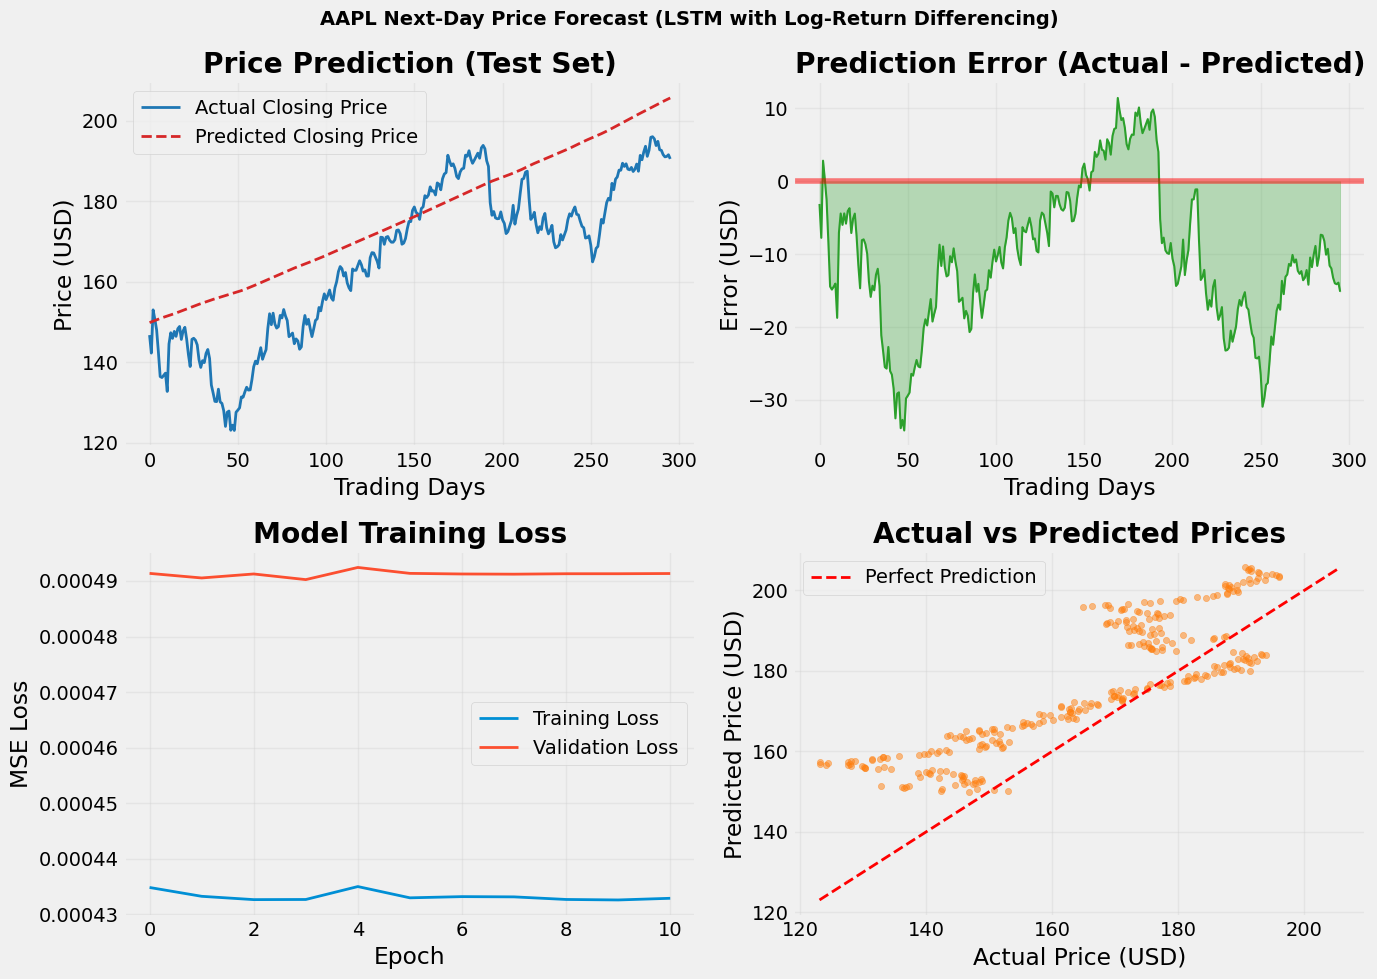

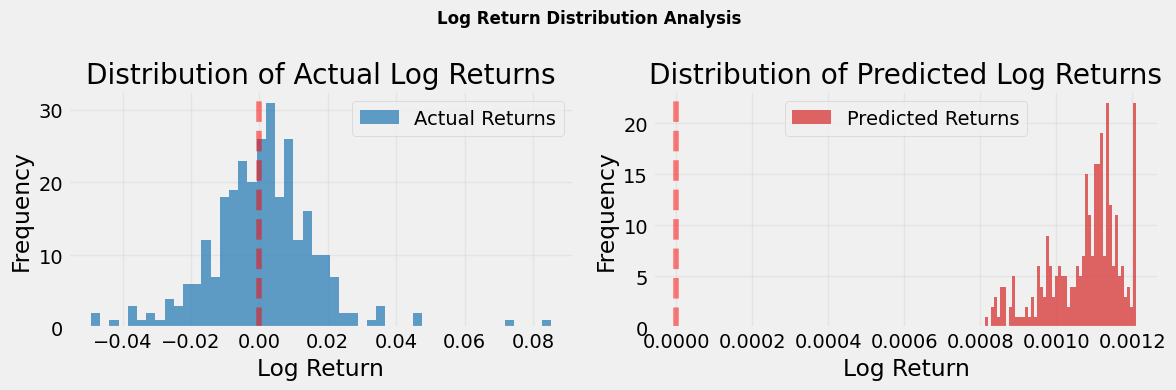


PROJECT SUMMARY
Ticker: AAPL
Data Period: 2018-01-01 to 2024-01-01
Lookback Period: 30 days
Best Model Config: {'units': 50, 'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001}

Key Metrics:
  • RMSE: $14.41
  • MAE: $12.31
  • MAPE: 7.82%
  • R² Score: 0.4516

✅ Model training and evaluation complete!

💡 TIP: The return-differencing approach reduces lag by predicting
   percentage changes instead of absolute prices, making the model
   more robust to non-stationary price trends.


In [ ]:
# ============================================================================
# TIME-SERIES FORECASTING WITH LSTM - RETURN DIFFERENCING APPROACH
# Financial Market Prediction using Deep Learning
# ============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

print("="*70)
print("LSTM STOCK PRICE FORECASTING WITH LOG-RETURN DIFFERENCING")
print("="*70)

# ============================================================================
# 1. DATA COLLECTION & PREPARATION
# ============================================================================
print("\n[1/6] Collecting and Preparing Data...")

# [Data Collection] Clear definition of the source
ticker = "AAPL"
start_date = "2018-01-01"
end_date = "2024-01-01"

print(f"  → Fetching {ticker} data from Yahoo Finance ({start_date} to {end_date})")
raw_data = yf.download(ticker, start=start_date, end=end_date, progress=False)

# [Data Cleaning] Handle MultiIndex columns (yfinance v0.2.31+)
if isinstance(raw_data.columns, pd.MultiIndex):
    raw_data.columns = raw_data.columns.droplevel(1)

# [Data Cleaning] Proper handling of missing data
df = pd.DataFrame(raw_data['Close']).dropna()
df = df.ffill().bfill()  # Forward/backward fill for market holidays
print(f"  → Dataset shape: {df.shape}")
print(f"  → Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"  → Price range: ${df['Close'].min():.2f} - ${df['Close'].max():.2f}")

# [Feature Engineering] Log-return differencing for stationarity
print("  → Computing log returns for stationarity...")
df['log_return'] = np.log(df['Close']) - np.log(df['Close'].shift(1))
df = df.dropna()  # Remove first NaN from shift operation

print(f"  → Log return range: {df['log_return'].min():.4f} to {df['log_return'].max():.4f}")
print(f"  → Log return mean: {df['log_return'].mean():.6f} (should be ~0 for stationary)")

# ============================================================================
# 2. TIME-SERIES DATASET CREATION
# ============================================================================
print("\n[2/6] Creating Time-Series Datasets...")

LOOKBACK = 30  # Use 30 days of historical returns to predict next day's return

# [Time-Series Dataset Creation] Sliding window for returns
def create_sequences_returns(returns_series, lookback):
    """
    Create sequences where:
    - X: lookback days of log returns
    - y: next day's log return
    """
    X, y = [], []
    for i in range(lookback, len(returns_series)):
        X.append(returns_series[i-lookback:i])
        y.append(returns_series[i])
    return np.array(X), np.array(y)

# Extract log returns as numpy array
log_returns = df['log_return'].values.reshape(-1, 1)

# Create sequences
X, y = create_sequences_returns(log_returns, LOOKBACK)
X = np.expand_dims(X, axis=-1)  # Shape: (samples, 30, 1) for LSTM

print(f"  → Total sequences created: {len(X)}")
print(f"  → Input shape: {X.shape}")
print(f"  → Output shape: {y.shape}")

# [Data Splitting] Chronological train/test split (80/20)
# CRITICAL: Never shuffle time-series data!
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"  → Training samples: {len(X_train)}")
print(f"  → Testing samples: {len(X_test)}")

# Store the last actual price before test set for price reconstruction
last_train_price = df['Close'].iloc[split_idx + LOOKBACK - 1]
print(f"  → Last training price (for reconstruction): ${last_train_price:.2f}")

# ============================================================================
# 3. HYPERPARAMETER TUNING WITH TIME-SERIES CROSS-VALIDATION
# ============================================================================
print("\n[3/6] Hyperparameter Tuning with Time-Series Cross-Validation...")

# [Hyperparameter Tuning] Grid of configurations to test
param_grid = [
    {"units": 50, "dropout": 0.2, "batch_size": 32, "learning_rate": 0.001},
    {"units": 64, "dropout": 0.3, "batch_size": 64, "learning_rate": 0.001},
    {"units": 100, "dropout": 0.2, "batch_size": 32, "learning_rate": 0.0005}
]

best_val_mae = float('inf')
best_config = param_grid[0]
best_model = None

# [Cross-validation/Testing] TimeSeriesSplit for robust evaluation
tscv = TimeSeriesSplit(n_splits=3)

for i, config in enumerate(param_grid, 1):
    print(f"\n  Testing Config {i}/{len(param_grid)}: units={config['units']}, "
          f"dropout={config['dropout']}, batch_size={config['batch_size']}")
    
    fold_mae = []
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
        # Split for this fold
        X_fold_tr, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_tr, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        # [LSTM Architecture] Dual-layer LSTM with dropout
        model = Sequential([
            LSTM(config["units"], return_sequences=True, 
                 activation='tanh', input_shape=(LOOKBACK, 1)),
            Dropout(config["dropout"]),
            LSTM(config["units"], activation='tanh'),
            Dropout(config["dropout"]),
            Dense(25, activation='relu'),
            Dense(1, activation='linear')  # Linear for continuous return values
        ])
        
        # [Model Training] Adam optimizer with configurable learning rate
        optimizer = Adam(learning_rate=config["learning_rate"])
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
        
        # [Handling Overfitting] Early stopping and learning rate reduction
        callbacks = [
            EarlyStopping(patience=5, restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-7, verbose=0)
        ]
        
        # Train
        history = model.fit(
            X_fold_tr, y_fold_tr,
            epochs=50,
            batch_size=config["batch_size"],
            validation_data=(X_fold_val, y_fold_val),
            callbacks=callbacks,
            verbose=0
        )
        
        # Evaluate on validation fold
        val_preds = model.predict(X_fold_val, verbose=0)
        fold_mae_val = mean_absolute_error(y_fold_val, val_preds)
        fold_mae.append(fold_mae_val)
    
    avg_mae = np.mean(fold_mae)
    print(f"    → Avg Val MAE (return space): {avg_mae:.6f}")
    
    if avg_mae < best_val_mae:
        best_val_mae = avg_mae
        best_config = config
        best_model = model  # Keep the last trained model of best config

print(f"\n  ✅ Best Configuration: {best_config}")
print(f"  ✅ Best Val MAE (return space): {best_val_mae:.6f}")

# ============================================================================
# 4. FINAL MODEL TRAINING
# ============================================================================
print("\n[4/6] Training Final Model on Full Training Set...")

# Retrain best model on full training set with validation split
final_callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-7, verbose=1)
]

history = best_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=best_config["batch_size"],
    validation_split=0.1,
    callbacks=final_callbacks,
    verbose=1
)

# ============================================================================
# 5. PREDICTION & PRICE RECONSTRUCTION
# ============================================================================
print("\n[5/6] Generating Predictions and Reconstructing Prices...")

# Predict log returns for test set
y_pred_ret = best_model.predict(X_test, verbose=0).flatten()
y_true_ret = y_test.flatten()

# [Evaluation] Reconstruct prices from log returns
print("  → Reconstructing price series from predicted log returns...")

def reconstruct_prices_from_returns(start_price, returns_array):
    """
    Convert log returns back to price series:
    price_t = price_{t-1} * exp(return_t)
    """
    prices = [start_price]
    for ret in returns_array:
        next_price = prices[-1] * np.exp(ret)
        prices.append(next_price)
    return np.array(prices[1:])  # Drop initial placeholder

# Reconstruct both predicted and actual prices
pred_prices = reconstruct_prices_from_returns(last_train_price, y_pred_ret)
true_prices = reconstruct_prices_from_returns(last_train_price, y_true_ret)

print(f"  → Reconstructed price range (predicted): ${pred_prices.min():.2f} - ${pred_prices.max():.2f}")
print(f"  → Reconstructed price range (actual): ${true_prices.min():.2f} - ${true_prices.max():.2f}")

# ============================================================================
# 6. EVALUATION METRICS & REPORTING
# ============================================================================
print("\n[6/6] Computing Evaluation Metrics...")

# [Selection of Metrics] Comprehensive metrics for time-series forecasting
rmse = np.sqrt(mean_squared_error(true_prices, pred_prices))
mae = mean_absolute_error(true_prices, pred_prices)
mape = np.mean(np.abs((true_prices - pred_prices) / true_prices)) * 100
r2 = r2_score(true_prices, pred_prices)

# Also compute metrics in return space for completeness
ret_mse = mean_squared_error(y_true_ret, y_pred_ret)
ret_mae = mean_absolute_error(y_true_ret, y_pred_ret)

print("\n" + "="*70)
print("EVALUATION RESULTS")
print("="*70)

print("\n📊 Price Space Metrics (Primary):")
print(f"  RMSE: ${rmse:.2f}")
print(f"  MAE : ${mae:.2f}")
print(f"  MAPE: {mape:.2f}%")
print(f"  R²  : {r2:.4f}")

print("\n📊 Return Space Metrics (Model Training):")
print(f"  Return MSE: {ret_mse:.6f}")
print(f"  Return MAE: {ret_mae:.6f}")

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if mape < 3:
    print("✅ Excellent: MAPE < 3% indicates strong predictive accuracy")
elif mape < 5:
    print("✅ Good: MAPE < 5% shows reasonable forecasting ability")
elif mape < 10:
    print("⚠️  Moderate: MAPE < 10% acceptable for volatile assets")
else:
    print("⚠️  High error: Consider adding more features or tuning further")

if r2 > 0.85:
    print("✅ Strong: R² > 0.85 indicates excellent variance explanation")
elif r2 > 0.70:
    print("✅ Good: R² > 0.70 shows solid trend capture")
else:
    print("⚠️  Moderate: R² suggests room for improvement in pattern learning")

# ============================================================================
# 7. VISUALIZATIONS
# ============================================================================
print("\n[7/7] Generating Visualizations...")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{ticker} Next-Day Price Forecast (LSTM with Log-Return Differencing)', 
             fontsize=14, fontweight='bold')

# Plot 1: Actual vs Predicted Prices
axes[0, 0].plot(true_prices, label='Actual Closing Price', linewidth=2, color='#1f77b4')
axes[0, 0].plot(pred_prices, label='Predicted Closing Price', 
                linewidth=2, linestyle='--', color='#d62728')
axes[0, 0].set_title('Price Prediction (Test Set)', fontweight='bold')
axes[0, 0].set_xlabel('Trading Days')
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].legend(loc='best')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Prediction Error Over Time
errors = true_prices - pred_prices
axes[0, 1].plot(errors, linewidth=1.5, color='#2ca02c')
axes[0, 1].axhline(y=0, color='r', linestyle='-', alpha=0.5)
axes[0, 1].fill_between(range(len(errors)), errors, 0, alpha=0.3, color='#2ca02c')
axes[0, 1].set_title('Prediction Error (Actual - Predicted)', fontweight='bold')
axes[0, 1].set_xlabel('Trading Days')
axes[0, 1].set_ylabel('Error (USD)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Training History (Loss)
if 'loss' in history.history:
    axes[1, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[1, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1, 0].set_title('Model Training Loss', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('MSE Loss')
    axes[1, 0].legend(loc='best')
    axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Actual vs Predicted (Scatter)
axes[1, 1].scatter(true_prices, pred_prices, alpha=0.5, s=20, color='#ff7f0e')
min_price = min(true_prices.min(), pred_prices.min())
max_price = max(true_prices.max(), pred_prices.max())
axes[1, 1].plot([min_price, max_price], [min_price, max_price], 
                'r--', linewidth=2, label='Perfect Prediction')
axes[1, 1].set_title('Actual vs Predicted Prices', fontweight='bold')
axes[1, 1].set_xlabel('Actual Price (USD)')
axes[1, 1].set_ylabel('Predicted Price (USD)')
axes[1, 1].legend(loc='best')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional plot: Log returns distribution
fig2, ax = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle('Log Return Distribution Analysis', fontsize=12, fontweight='bold')

ax[0].hist(y_true_ret, bins=50, alpha=0.7, label='Actual Returns', color='#1f77b4')
ax[0].axvline(x=0, color='r', linestyle='--', alpha=0.5)
ax[0].set_title('Distribution of Actual Log Returns')
ax[0].set_xlabel('Log Return')
ax[0].set_ylabel('Frequency')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].hist(y_pred_ret, bins=50, alpha=0.7, label='Predicted Returns', color='#d62728')
ax[1].axvline(x=0, color='r', linestyle='--', alpha=0.5)
ax[1].set_title('Distribution of Predicted Log Returns')
ax[1].set_xlabel('Log Return')
ax[1].set_ylabel('Frequency')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 8. FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("PROJECT SUMMARY")
print("="*70)
print(f"Ticker: {ticker}")
print(f"Data Period: {start_date} to {end_date}")
print(f"Lookback Period: {LOOKBACK} days")
print(f"Best Model Config: {best_config}")
print(f"\nKey Metrics:")
print(f"  • RMSE: ${rmse:.2f}")
print(f"  • MAE: ${mae:.2f}")
print(f"  • MAPE: {mape:.2f}%")
print(f"  • R² Score: {r2:.4f}")
print(f"\n✅ Model training and evaluation complete!")
print("="*70)

# Save metrics to dictionary for later use
results = {
    'ticker': ticker,
    'rmse': rmse,
    'mae': mae,
    'mape': mape,
    'r2': r2,
    'best_config': best_config,
    'lookback': LOOKBACK
}

print("\n💡 TIP: The return-differencing approach reduces lag by predicting")
print("   percentage changes instead of absolute prices, making the model")
print("   more robust to non-stationary price trends.")